<a href="https://colab.research.google.com/github/Rohim110606/AbdulRohim_2411533015_ML2526/blob/main/Praktikum3/LogistikRegressionBreastCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset
dataset_url = 'https://raw.githubusercontent.com/Rohim110606/AbdulRohim_2411533015_ML2526/refs/heads/main/Praktikum3/Breast_cancer_data.csv'
df = pd.read_csv(dataset_url)
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


<Axes: title={'center': 'diagnosis'}>

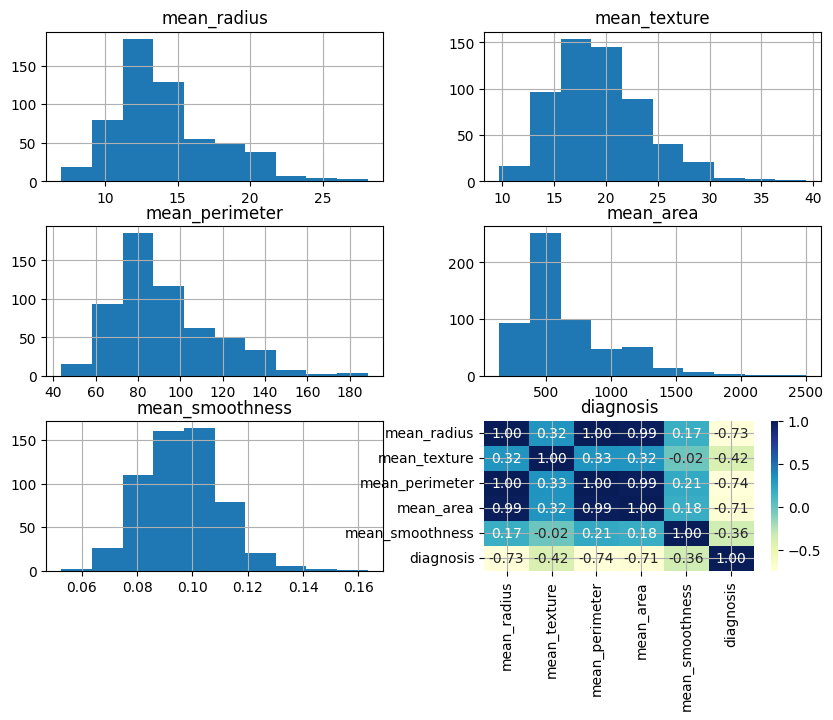

In [3]:
df.hist(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap="YlGnBu", fmt=".2f")

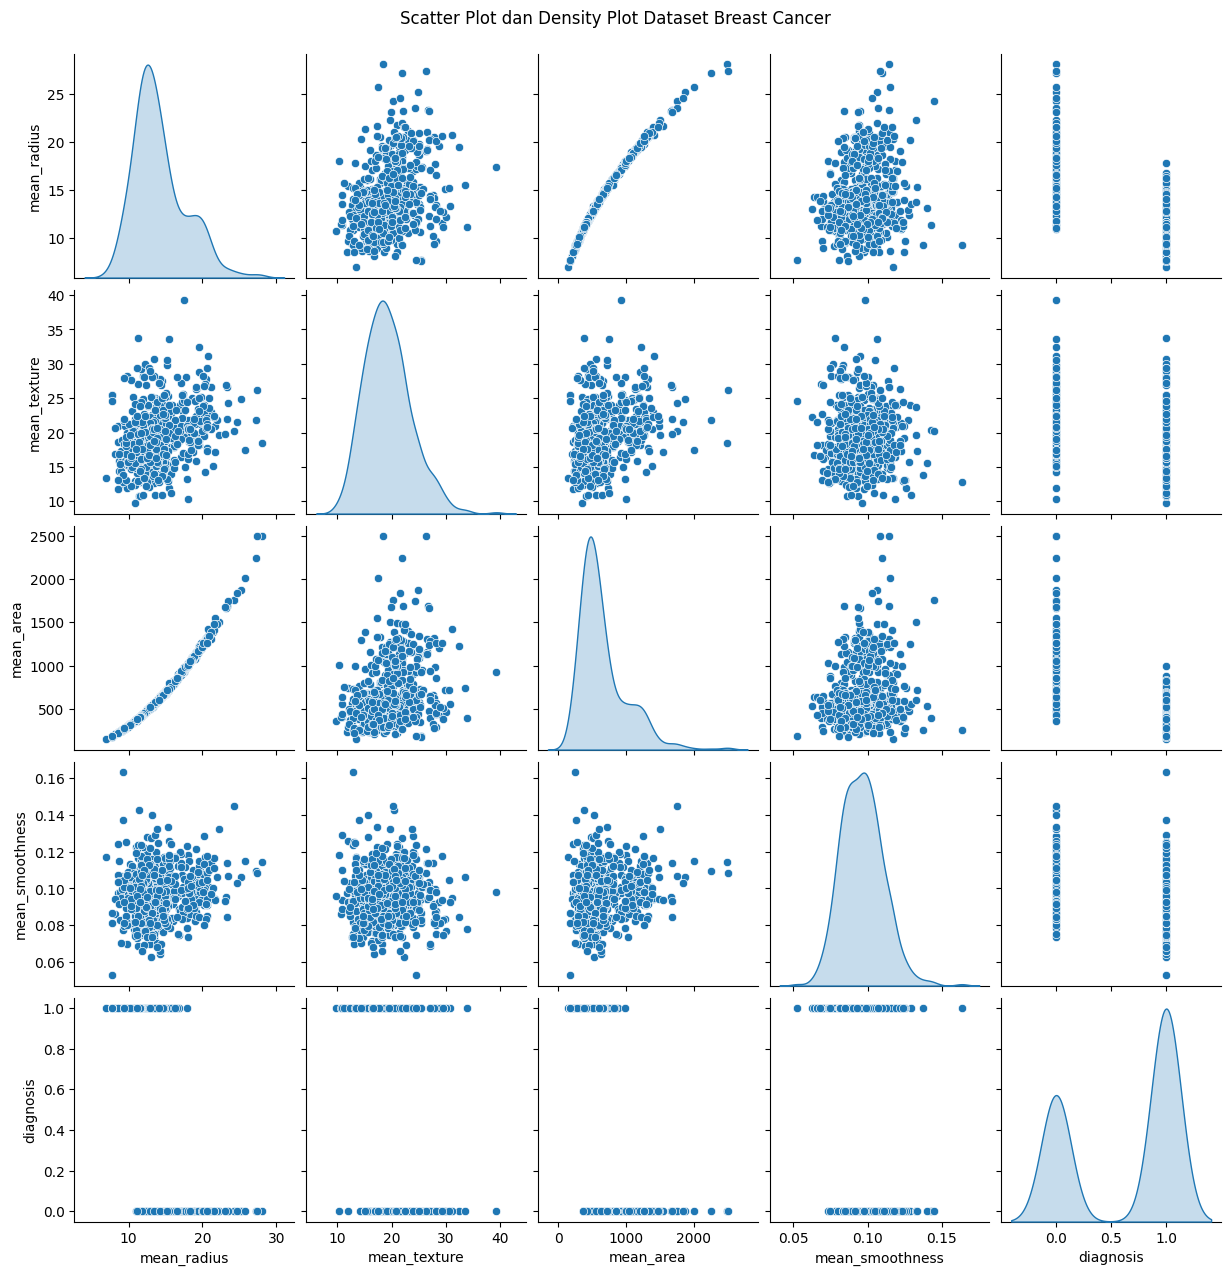

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['mean_radius', 'mean_texture', 'mean_area', 'mean_smoothness', 'diagnosis']

sns.pairplot(df[cols], diag_kind='kde')
plt.suptitle('Scatter Plot dan Density Plot Dataset Breast Cancer', y=1.02)
plt.show()

In [6]:
feature_cols = ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
'mean_smoothness']
X = df[feature_cols]
y = df['diagnosis']

print(X.shape)
print(y.shape)

(569, 5)
(569,)


In [17]:
logreg = LogisticRegression(random_state=16)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
y_pred

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0])

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

model_ns = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=16, max_iter=1000)
)

model_ns.fit(X_train, y_train)
y_pred_ns = model_ns.predict(X_test)

In [9]:
model_ns = LogisticRegression(random_state=16, max_iter=1000)
model_ns.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=16)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


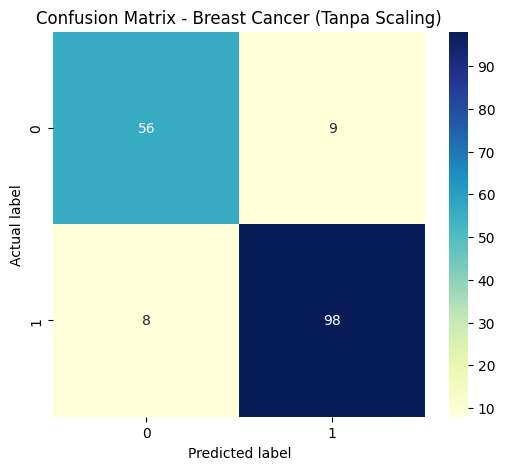

              precision    recall  f1-score     support
malignant      0.875000  0.861538  0.868217   65.000000
benign         0.915888  0.924528  0.920188  106.000000
accuracy       0.900585  0.900585  0.900585    0.900585
macro avg      0.895444  0.893033  0.894202  171.000000
weighted avg   0.900346  0.900585  0.900433  171.000000


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=16
)

model_ns = LogisticRegression(random_state=16)
model_ns.fit(X_train, y_train)
y_pred_ns = model_ns.predict(X_test)

cm = confusion_matrix(y_test, y_pred_ns)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Confusion Matrix - Breast Cancer (Tanpa Scaling)')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.show()

report_dict = classification_report(
    y_test, y_pred_ns,
    target_names=['malignant', 'benign'],
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
print(report_df)

In [12]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model_sc = LogisticRegression(random_state=16)
model_sc.fit(X_train_sc, y_train)
y_pred_sc = model_sc.predict(X_test_sc)

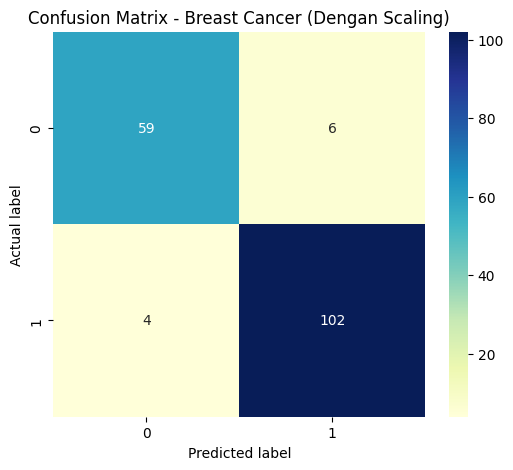

              precision    recall  f1-score   support

   malignant       0.94      0.91      0.92        65
      benign       0.94      0.96      0.95       106

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model_sc = LogisticRegression(random_state=16)
model_sc.fit(X_train_sc, y_train)
y_pred_sc = model_sc.predict(X_test_sc)

cm_sc = confusion_matrix(y_test, y_pred_sc)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_sc, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Confusion Matrix - Breast Cancer (Dengan Scaling)')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.show()

print(classification_report(y_test, y_pred_sc, target_names=['malignant', 'benign']))

In [14]:
y_prob = model_sc.predict_proba(X_test_sc)[:, 1]

y_pred_03 = (y_prob >= 0.3).astype(int)
y_pred_05 = (y_prob >= 0.5).astype(int)
y_pred_07 = (y_prob >= 0.7).astype(int)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

thresholds = [0.3, 0.5, 0.7]
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    results.append([
        t,
        accuracy_score(y_test, y_pred_t),
        precision_score(y_test, y_pred_t),
        recall_score(y_test, y_pred_t),
        f1_score(y_test, y_pred_t)
    ])

threshold_df = pd.DataFrame(
    results,
    columns=['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
)

print(threshold_df)

   Threshold  Accuracy  Precision    Recall  F1-Score
0        0.3  0.935673   0.913043  0.990566  0.950226
1        0.5  0.941520   0.944444  0.962264  0.953271
2        0.7  0.912281   0.959596  0.896226  0.926829
